# Polynomial Regression

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('EconomiesOfScale.csv')
df.sample(10)

,Number of Units,Manufacturing Cost
289,3.746876,45.465798
793,5.514347,32.653247
484,4.384275,40.157148
172,3.187436,38.220998
486,4.398994,42.036711
51,2.305669,75.521970
868,5.910108,37.869092
625,4.923699,46.097425
618,4.879510,32.271427
196,3.309800,38.497367


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [ ]:
df.describe()

,Number of Units,Manufacturing Cost
count,1000.000000,1000.000000
mean,4.472799,40.052999
std,1.336241,10.595322
min,1.000000,20.000000
25%,3.594214,32.912036
50%,4.435958,38.345781
75%,5.324780,44.531822
max,10.000000,100.000000


# Data Visualization

<Figure size 1280x960 with 0 Axes>

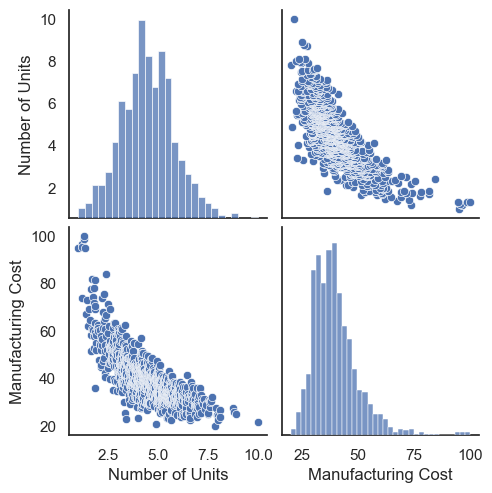

In [ ]:
sns.set_theme(style="white")
plt.figure(dpi = (200))
sns.pairplot(df)

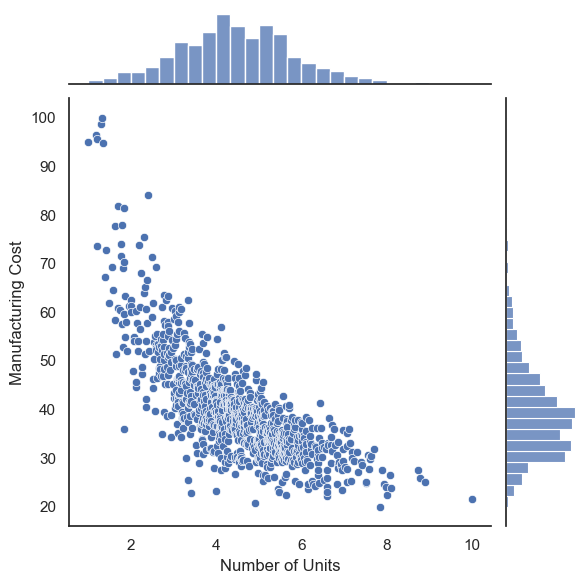

In [ ]:
sns.jointplot(x='Number of Units', y='Manufacturing Cost', data = df)

<Figure size 640x480 with 0 Axes>

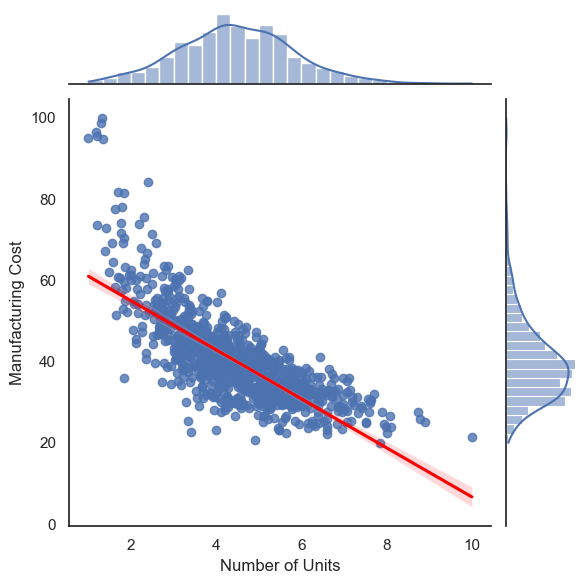

In [ ]:
sns.set_theme(style="white")
plt.figure(dpi = (100))
sns.jointplot(x = df['Number of Units'], y = df['Manufacturing Cost'], kind='reg', line_kws={"color": "red"})

<Axes: xlabel='Number of Units', ylabel='Manufacturing Cost'>

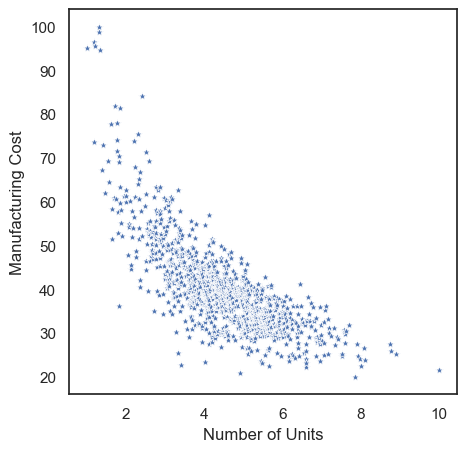

In [ ]:
plt.figure(figsize = (5,5), dpi = (100))
sns.scatterplot(x = df['Number of Units'], y = df['Manufacturing Cost'], marker="*")

# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Number of Units']]
y = df['Manufacturing Cost']

# We are using entire dataset for training
X_train = X
y_train = y

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****"*10)

Total # of sample in whole dataset: 1000
**************************************************
Total # of sample in train dataset: 1000
Shape of X_train: (1000, 1)
**************************************************


# Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=6)

In [ ]:
X_columns = poly_regressor.fit_transform(X_train)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_columns, y_train)

pred = model.predict(poly_regressor.fit_transform(X_train))

Text(0.5, 1.0, 'Unit Cost vs. Number of Units [in Millions](Training dataset)')

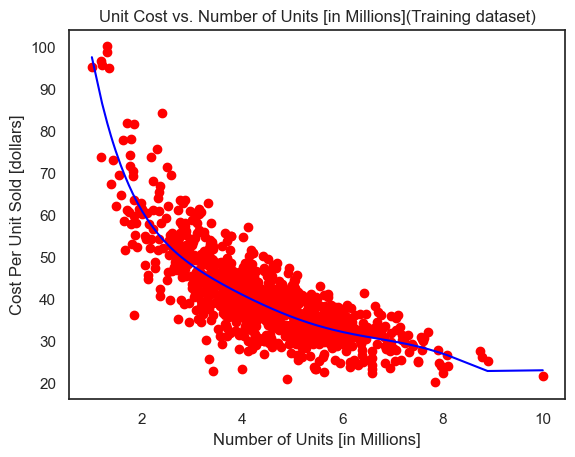

In [ ]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, pred, color = 'blue')
plt.ylabel('Cost Per Unit Sold [dollars]')
plt.xlabel('Number of Units [in Millions]')
plt.title('Unit Cost vs. Number of Units [in Millions](Training dataset)')

# Optimal Degree

In [ ]:
j = 0
plt.figure(figsize=(150,150))

for i in range(1,11):
    poly_regressor = PolynomialFeatures(degree=i)
    X_columns = poly_regressor.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_columns, y_train)

    pred = model.predict(poly_regressor.fit_transform(X_train))

    plt.subplot(5,2,j+1)
    plt.scatter(X_train, y_train, color = 'red', s = 115)
    plt.plot(X_train, pred, color = 'blue',linewidth = 5.5)
    plt.ylabel('Cost Per Unit Sold [dollars]')
    plt.xlabel('Number of Units [in Millions]')
    plt.title(f'Unit Cost vs. Number of Units [in Millions](Training dataset) - Degree =  {i}',color = 'black',fontsize = 75)
    j += 1